<a href="https://colab.research.google.com/github/AgustinBiasca/Logistic-Regression/blob/main/The_Stock_Market_Binomial_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ISLP

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
import seaborn as sns
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize)

from ISLP import confusion_table
from ISLP.models import contrast
from sklearn.discriminant_analysis import \
    (LinearDiscriminantAnalysis as LDA,
     QuadraticDiscriminantAnalysis as QDA)

from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [ ]:
Smarket = load_data('Smarket')
Smarket.columns

Index(['Year', 'Lag1', 'Lag2', 'Lag3', 'Lag4', 'Lag5', 'Volume', 'Today',
       'Direction'],
      dtype='object')

This data set consists of percentage returns for the S&P 500 stock index over 1,250 days, from the beginning of 2001 until the end of 2005. For each date, we have recorded the percentage returns for each of the five previous trading days, Lag1 through Lag5. We have also recorded Volume (the number of shares traded on the previous day, in billions), Today (the percentage return on the date in question) and Direction (whether the market was Up or Down on this date).

In [ ]:
Smarket.dtypes

,0
Year,int64
Lag1,float64
Lag2,float64
Lag3,float64
Lag4,float64
Lag5,float64
Volume,float64
Today,float64
Direction,category


Siempre va a ser interesante crear una matriz de correlacion para ver los resultados. En nuestro dataset, direction es una variable categorica "down" y "up" por lo tanto vamos a eliminarla y ver el grado de relacion de las otras variables.

para ver mas claro la relacion. Vamos a hacer un heatmap

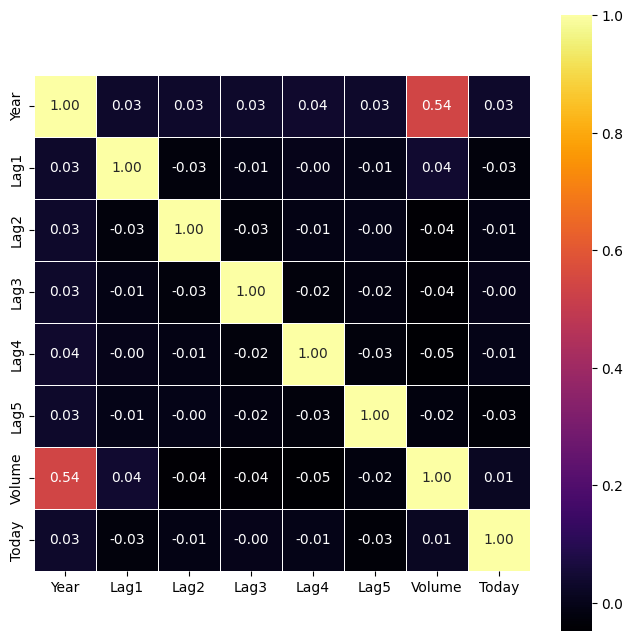

In [ ]:
smarket_num = Smarket.drop(columns=['Direction'])

corr_matrix = smarket_num.corr()

plt.figure(figsize=(8, 8))

sns.heatmap(corr_matrix , annot = True, cmap='inferno', fmt='.2f', square=True, linewidths= 0.5)

plt.show()

 As one would expect, the correlations between the lagged return variables
 and today’s return are close to zero. The only substantial correlation is
 between Year and Volume.

<Axes: >

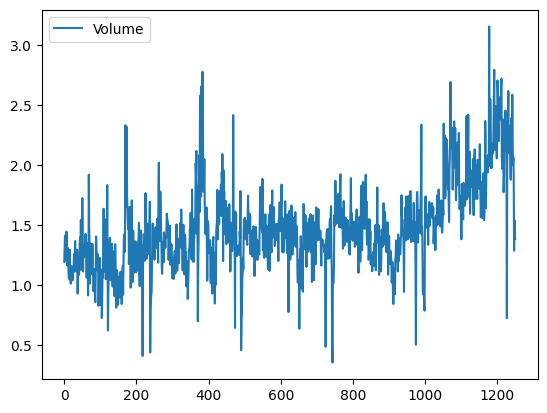

In [ ]:
Smarket.plot(y='Volume')


el gráfico muestra cómo cambia el volumen de transacciones a lo largo de las observaciones del dataset.

Va de 0 a 1200 aproximadamente porque el dataset Smarket tiene 1250 observaciones (días de mercado).



In [ ]:
allvars = Smarket.columns.drop(['Today', 'Direction', 'Year'])
design = MS(allvars)

X = design.fit_transform(Smarket)
y = Smarket.Direction == 'Up'

glm = sm.GLM (y,
              X,
              family = sm.families.Binomial ())
results = glm.fit()
summarize(results)

,coef,std err,z,P>|z|
intercept,-0.1260,0.241,-0.523,0.601
Lag1,-0.0731,0.050,-1.457,0.145
Lag2,-0.0423,0.050,-0.845,0.398
Lag3,0.0111,0.050,0.222,0.824
Lag4,0.0094,0.050,0.187,0.851
Lag5,0.0103,0.050,0.208,0.835
Volume,0.1354,0.158,0.855,0.392


El valor p más bajo aquí se asocia con Lag1. El coeficiente negativo de este predictor sugiere que si el mercado tuvo una rentabilidad positiva ayer, es menos probable que suba hoy. Sin embargo, con un valor de 0,15, el valor p sigue siendo relativamente alto, por lo que no hay evidencia clara de una asociación real entre Lag1 y la Dirección.

In [ ]:
display(results.params)

display (results.pvalues)

,0
intercept,-0.126000
Lag1,-0.073074
Lag2,-0.042301
Lag3,0.011085
Lag4,0.009359
Lag5,0.010313
Volume,0.135441


,0
intercept,0.600700
Lag1,0.145232
Lag2,0.398352
Lag3,0.824334
Lag4,0.851445
Lag5,0.834998
Volume,0.392404


Recuerde que si el coeficiente es negativo, la relación con Y es inversa.

Un valor p alto significa que la variable X no es relevante en nuestro modelo. En este caso, estas variables no nos ayudan a predecir si el mercado subirá o bajará.

Ahora intentamos entrenar los datos y comprobar si los resultados tienen lógica.


In [ ]:
probs = results.predict()
probs[:10]

array([0.50708413, 0.48146788, 0.48113883, 0.51522236, 0.51078116,
       0.50695646, 0.49265087, 0.50922916, 0.51761353, 0.48883778])

Esta matriz representa la probabilidad de que el mercado suba. Por ejemplo, el primer índice de la matriz indica que la probabilidad de que el mercado abra al alza es del 50,708 %.

Para predecir si el mercado subirá o bajará en un día determinado, debemos convertir estas probabilidades en etiquetas de clase: up o down. Los dos comandos siguientes crean un vector de predicciones de clase según si la probabilidad de un aumento del mercado es mayor o menor que 0,5.


In [ ]:
labels = np.array(['Down']*1250)
labels[probs > 0.5] = "Up"

display(labels[:10])

array(['Up', 'Down', 'Down', 'Up', 'Up', 'Up', 'Down', 'Up', 'Up', 'Down'],
      dtype='<U4')

La función confusion_table() del paquete ISLP resume estas predicciones, mostrando cuántas observaciones fueron clasificadas correctamente o incorrectamente. Nuestra función, que está adaptada de una función similar del módulo sklearn.metrics, transpone la matriz resultante e incluye etiquetas de filas y columnas. La función confusion_table() toma como primer argumento las etiquetas predichas, y como segundo argumento las etiquetas verdaderas.

In [ ]:
confusion_table(labels, Smarket.Direction) #Direction is the response

Truth,Down,Up
Predicted,,
Down,145,141
Up,457,507


Los elementos diagonales de la matriz de confusión indican predicciones correctas, mientras que los elementos fuera de la diagonal representan predicciones incorrectas. Por lo tanto, nuestro modelo predijo correctamente que el mercado subiría en 507 días y que bajaría en 145 días, para un total de 507 + 145 = 652 predicciones correctas.

In [ ]:
np.mean(labels == Smarket.Direction)

np.float64(0.5216)

La función np.mean() permite calcular la fracción de días en los que la predicción fue correcta. En este caso, la regresión logística predijo correctamente el movimiento del mercado el 52,2 % de las veces.

El párrafo señala un problema importante: aunque el modelo de regresión logística parece funcionar un poco mejor que adivinar al azar, ese resultado es engañoso porque se entrenó y se evaluó usando exactamente los mismos datos (las 1.250 observaciones). En otras palabras, el modelo fue probado con los mismos ejemplos que utilizó para aprender, lo cual produce un error de entrenamiento (training error rate) del 47,8 %. Este error no refleja el desempeño real del modelo, porque al haber visto esos datos durante el entrenamiento, el modelo puede “memorizar” patrones específicos en lugar de aprender relaciones generales. Por eso, el error de entrenamiento suele ser demasiado optimista, ya que subestima el error que cometería el modelo sobre datos nuevos.

En la práctica, lo que realmente nos interesa es saber qué tan bien predice el modelo cuando enfrenta datos desconocidos, es decir, su error de prueba (test error rate). Para estimarlo de manera realista, debemos dividir los datos en dos conjuntos: uno para entrenar el modelo y otro para probarlo. De esa forma, podemos evaluar cómo se comporta ante observaciones que no ha visto antes, tal como ocurriría en el futuro cuando queramos predecir movimientos del mercado aún desconocidos. En resumen, evaluar un modelo con los mismos datos que se usaron para entrenarlo da una impresión falsa de precisión; solo al probarlo con datos nuevos obtenemos una medida confiable de su capacidad de generalización.

Para llevar a cabo esto vamos a entrenar nuestro modelo con los datos de los años 2001 hasta 2004 y vamos a probabr con los datos de 2005. Segun el nivel de correlacion vamos a saber si nuestro modelo aprendio o memorizo.

In [ ]:
train = (Smarket.Year < 2005)


Smarket_train = Smarket.loc[train]

Smarket_test = Smarket.loc[~train]
Smarket_test.shape

(252, 9)

El objeto train es un vector de 1,250 elementos, que corresponde a las observaciones en nuestro conjunto de datos. Los elementos del vector que corresponden a observaciones que ocurrieron antes de 2005 se establecen en True, mientras que aquellos que corresponden a observaciones en 2005 se establecen en False. Por lo tanto, train es un arreglo booleano, ya que sus elementos son True y False. Los arreglos booleanos se pueden usar para obtener un subconjunto de las filas o columnas de un marco de datos utilizando el método loc.

Por ejemplo, el comando Smarket.loc[train] seleccionaría una submatriz del conjunto de datos del mercado de valores, correspondiente únicamente a las fechas anteriores a 2005, ya que esas son las fechas para las cuales los elementos de train son True. El símbolo ~ se puede usar para negar todos los elementos de un vector booleano.

Smarket.loc[~train] produce un subconjunto de las filas del marco de datos del mercado de valores que contiene solo las observaciones para las cuales train es False. El resultado anterior indica que hay 252 de tales observaciones.


Ahora ajustamos un modelo de regresión logística utilizando solo el subconjunto de las observaciones que corresponden a fechas anteriores a 2005. Luego obtenemos las probabilidades predichas de que el mercado de valores suba para cada uno de los días en nuestro conjunto de prueba, es decir, para los días en 2005.

In [ ]:
X_train, X_test = X.loc[train] , X.loc[~train]

y_train, y_test = y.loc[train] , y.loc[~train]

glm_train = sm.GLM (y_train,
              X_train,
              family = sm.families.Binomial())

results = glm_train.fit()
probs = results.predict(exog=X_test)

Observe que hemos entrenado y probado nuestro modelo en dos conjuntos de datos completamente separados: el entrenamiento se realizó utilizando únicamente las fechas anteriores a 2005, y la prueba se realizó utilizando únicamente las fechas de 2005. Finalmente, comparamos las predicciones para 2005 con los movimientos reales del mercado durante ese período. Primero almacenaremos las etiquetas de prueba y de entrenamiento (recuerde que y_test es binario)

In [ ]:
D = Smarket.Direction
L_train , L_test = D.loc[train] , D.loc[~train]

In [ ]:
labels = np.array(['Down'] * 252)  #252 files and 9 columns
labels[probs > 0.5] = 'Up'
confusion_table(labels, L_test)

Truth,Down,Up
Predicted,,
Down,77,97
Up,34,44


In [ ]:
np.mean(labels == L_test)

np.float64(0.4801587301587302)

La precision ddel modelo es del 48%

In [ ]:
np.mean(labels != L_test)

np.float64(0.5198412698412699)

La tasa de error es delt 52%

A continuación, ajustamos nuevamente la regresión logística utilizando solo Lag1 y Lag2, que parecían tener el mayor poder predictivo en el modelo de regresión logística original

In [ ]:
model = MS(['Lag1', 'Lag2']).fit(Smarket)
X = model.transform(Smarket)

X_train , X_test = X.loc[train] , X.loc[~train]

glm_train = sm.GLM(y_train,
                   X_train,
                   family= sm.families.Binomial())

results = glm_train.fit()
probs = results.predict(X_test)

labels = np.array(["Down"]*252)
labels[probs > 0.5] = "Up"

confusion_table(labels , L_test)

Truth,Down,Up
Predicted,,
Down,35,35
Up,76,106


In [ ]:
np.mean(labels == L_test), np.mean(labels != L_test)

(np.float64(0.5595238095238095), np.float64(0.44047619047619047))

Ahora los resultados parecen ser un poco mejores: el 56% de los movimientos diarios se han predicho correctamente. Cabe destacar que, en este caso, una estrategia mucho más simple de predecir que el mercado aumentará cada día también sería correcta el 56% del tiempo.

Esto sugiere una posible estrategia de comercio de comprar en los días en que el modelo predice un mercado en aumento y evitar operaciones en los días en que se predice una disminución. Por supuesto, sería necesario investigar con más cuidado si esta pequeña mejora era real o simplemente debida al azar.

Supongamos que queremos predecir los rendimientos asociados con valores particulares de Lag1 y Lag2. En particular, queremos predecir la Dirección en un día en que Lag1 y Lag2 sean 1.2 y 1.1, respectivamente, y en un día en que sean 1.5 y 0.8. Hacemos esto utilizando la función predict().

In [ ]:
newdata = pd.DataFrame({'Lag1': [1.2, 1.5],     #both data
                        'Lag2' : [1.1, -0.8]})

newX = model.transform(newdata)
results.predict(newX)

,0
0,0.479146
1,0.496094


La probabilidad de que el mercado suba en el caso de lag1 = 1.2 y lag2 = 1.1 es igual a 47.9%.

Minetras que la probabilidad de que suba con lag1 = 1.5 y lag2 = -0.8 es del 49.6%